<h1 style="text-align: center;">Fraud Detections & Data Quality Analysis Of GrabUnlimited Transactions In GrabFood</h1>
<h3 style="text-align: center;">Zian Carlos Wong & Valencia</h3>

---

In [546]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [547]:
df_food_orders_raw = pd.read_csv("../data/raw/grab_food_orders.csv")
df_merchants_raw = pd.read_csv("../data/raw/grab_merchants.csv")
df_users_raw = pd.read_csv("../data/raw/grab_users.csv")

df_food_orders_cleaned = df_food_orders_raw.copy()
df_merchants_cleaned = df_merchants_raw.copy()
df_users_cleaned = df_users_raw.copy()

In [548]:
df_food_orders_cleaned.head()

,order_id,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time
0,GF-ORD-00000001,GF-06555,GB-019659,Completed,0,NaN,2023-12-21 09:43:00,2023-12-21 10:00:00,2023-12-21 10:16:00
1,GF-ORD-00000002,GF-07698,GB-019520,Cancel,0,Resto Tidak Ditemukan,2023-12-20 14:01:00,2023-12-20 14:13:00,NaN
2,GF-ORD-00000003,GF-02054,GB-030006,CANCELED,15000,Menu Habis,2024-02-18 12:56:00,2024-02-18 13:06:00,NaN
3,GF-ORD-00000004,GF-05867,GB-021929,Completed,30000,NaN,2023-12-21 16:12:00,2023-12-21 16:24:00,2023-12-21 16:58:00
4,GF-ORD-00000005,GF-06915,GB-008802,DONE,0,NaN,2024-02-03 09:13:00,2024-02-03 09:20:00,2024-02-03 09:36:00


In [549]:
df_merchants_cleaned.head()

,merchant_id,merchant_name,cuisine_type,city
0,GF-00001,Resto GrabMantap 0,Seafood,Depok
1,GF-00002,Resto GrabMantap 1,Fast Food,Surabaya
2,GF-00003,Resto GrabMantap 2,Martabak,Tangerang
3,GF-00004,Resto GrabMantap 3,Martabak,Jakarta
4,GF-00005,Resto GrabMantap 4,Snacks,Bekasi


In [550]:
df_users_cleaned.head()

,user_id,is_grab_unlimited,account_age_days
0,GB-000001,False,91
1,GB-000002,False,1048
2,GB-000003,True,985
3,GB-000004,True,1357
4,GB-000005,False,16


## **Section 1. Business Context**

**1.1 Context**

    Grab meluncurkan program subscription GrabUnlimited untuk meningkatkan retensi pelanggan dalam ekosistem Grab dengan membayar biaya layanan bulanan untuk mendapatkan voucher gratis ongkir dan diskon untuk setiap pemesanan GrabFood.

    Strategi ini sukses membuat jumlah frekuensi transaksi meningkat, tetapi terdapat aktifitas fraud dengan cara membuat resto fiktif dan memesan makanan fiktif ke resto tersebut. Oleh karena itu, Grab harus menanggung kerugian yang besar akibat mensubsidi diskon makanan dan biaya ongkir serta pembatalan pesanan mengakibatkan kerusakan metrik performa operasional.
    
    Tim Data Engineer dan Fraud Analyst mengalami kesulitan untuk mengidentifikasi aktifitas fraud akibat kualitas data yang buruk seperti alasan pembatalan yang seringkali tidak konsisten dan dibiarkan kosong serta terdapat bug sistem yang memungkinkan pesanan selesai tanpa menunggu driver tiba di titik penjemputan. Oleh karena itu, diperlukan analisis data untuk mengidentifikasi pola transaksi mencurigakan pada pemakaian GrabUnlimited.

**1.2 Problem Statements**

Masalah Utama: Kerugian finansial yang masif akibat eksploitasi subsidi GrabUnlimited oleh sindikat Resto Fiktif serta tingginya Cancellation Rate yang merugikan driver organik.

Masalah Turunan:
1.	Merchant mana saja yang memiliki rasio transaksi sukses sangat tinggi, tetapi pembelinya hanya berasal dari 2-3 akun user yang sama secara terus-menerus?
2.	Berapa estimasi uang subsidi promo (GrabUnlimited) yang terbuang sia-sia untuk transaksi yang terindikasi fiktif?
3.	Seberapa kotor dan tidak konsistennya penulisan status pesanan dan alasan pembatalan di dalam database?
4.	Berapa persentase pesanan batal yang tidak memiliki keterangan Cancel Reason (Missing Values), sehingga menyulitkan investigasi tim operasional?
5.	(Logical Error) Berapa banyak pesanan berstatus 'Completed' di mana jam 'Pesanan Selesai' (Completed Time) terjadi sebelum jam 'Driver Tiba di Resto' (Driver Arrived Time)?
6.	Kategori makanan (Cuisine Type) apa yang paling sering digunakan sebagai kedok oleh Resto Fiktif untuk memanipulasi harga menu tinggi?


**1.3 Key Objective**

1. Mengidentifikasi merchant yang terindentifikasi sebagai resto fiktif
2. Mengestimasi kerugian finasial dari uang promo yang terbuang akibat transaksi fiktif
3. Mengidentifikasi inkonsistensi dan melakukan standarisasi penulisan database seperti status pesanan serta mengidentifikasi dan melakukan penanganan terhadap missing values
4. Mendeteksi anomali / nilai ekstrem pada data

## **Section 2. Data Understanding**

**2.1 General Information**

In [551]:
df_food_orders_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   order_id             300000 non-null  object
 1   merchant_id          300000 non-null  object
 2   user_id              300000 non-null  object
 3   order_status         300000 non-null  object
 4   promo_discount       300000 non-null  int64 
 5   cancel_reason        35780 non-null   object
 6   order_time           300000 non-null  object
 7   driver_arrived_time  270320 non-null  object
 8   completed_time       240093 non-null  object
dtypes: int64(1), object(8)
memory usage: 20.6+ MB


In [552]:
df_merchants_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   merchant_id    8000 non-null   object
 1   merchant_name  8000 non-null   object
 2   cuisine_type   8000 non-null   object
 3   city           8000 non-null   object
dtypes: object(4)
memory usage: 250.1+ KB


In [553]:
df_users_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            40000 non-null  object
 1   is_grab_unlimited  40000 non-null  bool  
 2   account_age_days   40000 non-null  int64 
dtypes: bool(1), int64(1), object(1)
memory usage: 664.2+ KB


In [554]:
print("food orders table shape:", df_food_orders_cleaned.shape)
print("merchant table shape:", df_merchants_cleaned.shape)
print("users table shape:", df_users_cleaned.shape)

food orders table shape: (300000, 9)
merchant table shape: (8000, 4)
users table shape: (40000, 3)


**2.2 Feature Information**

In [555]:
print("Food orders Table list of colums:", df_food_orders_cleaned.columns.tolist())
print("Merchants Table list of colums:", df_merchants_cleaned.columns.tolist())
print("Users Table list of colums:", df_users_cleaned.columns.tolist())


Food orders Table list of colums: ['order_id', 'merchant_id', 'user_id', 'order_status', 'promo_discount', 'cancel_reason', 'order_time', 'driver_arrived_time', 'completed_time']
Merchants Table list of colums: ['merchant_id', 'merchant_name', 'cuisine_type', 'city']
Users Table list of colums: ['user_id', 'is_grab_unlimited', 'account_age_days']


In [556]:
print("Food Orders Table Each Column Null Values Sum")
display(df_food_orders_cleaned.isnull().sum())


Food Orders Table Each Column Null Values Sum


order_id                    0
merchant_id                 0
user_id                     0
order_status                0
promo_discount              0
cancel_reason          264220
order_time                  0
driver_arrived_time     29680
completed_time          59907
dtype: int64

In [557]:
print("Merchants Table Each Column Null Values Sum")
display(df_merchants_cleaned.isnull().sum())


Merchants Table Each Column Null Values Sum


merchant_id      0
merchant_name    0
cuisine_type     0
city             0
dtype: int64

In [558]:
print("Users Table Each Column Null Values Sum")
display(df_users_cleaned.isnull().sum())


Users Table Each Column Null Values Sum


user_id              0
is_grab_unlimited    0
account_age_days     0
dtype: int64

**2.3 Statistics Summary**

In [559]:
df_food_orders_cleaned.describe()

,promo_discount
count,3.000000e+05
mean,6.035158e+04
std,7.018429e+05
min,-5.000000e+03
25%,0.000000e+00
50%,1.000000e+04
75%,2.000000e+04
max,9.999999e+06


In [560]:
df_merchants_cleaned.describe()

,merchant_id,merchant_name,cuisine_type,city
count,8000,8000,8000,8000
unique,8000,8000,6,10
top,GF-00001,Resto GrabMantap 0,Ayam Geprek,Bekasi
freq,1,1,1388,861


In [561]:
df_users_cleaned.describe()

,account_age_days
count,40000.000000
mean,750.897150
std,431.156788
min,1.000000
25%,378.000000
50%,753.000000
75%,1122.000000
max,1499.000000


## **Section 3. Data Cleaning**

**3.1 Duplicated Values**

In [562]:
# (3.1.1.1) Check duplicate rows in dataset
# Step: Identify fully duplicated records across all columns

print("Food Orders Duplicated Rows:", df_food_orders_cleaned.duplicated().sum())
print("Merchants Duplicated Rows:",df_merchants_cleaned.duplicated().sum())
print("Users Duplicated Rows:",df_users_cleaned.duplicated().sum())

Food Orders Duplicated Rows: 0
Merchants Duplicated Rows: 0
Users Duplicated Rows: 0


In [ ]:
# (3.1.2.1) Check duplicate rows in dataset primary key & must unique columns
# Step: Identify fully duplicated records across all columns

print("Food Orders Primary Key Is Unique:", df_food_orders_cleaned["order_id"].is_unique)
print("Merchants Id Primary Key Is Unique:",df_merchants_cleaned["merchant_id"].is_unique)
print("Merchants Name Is Unique:",df_merchants_cleaned["merchant_name"].is_unique)
print("Users Primary Key Is Unique:",df_users_cleaned["user_id"].is_unique)

Food Orders Primary Key Is Unique: True
Merchants Duplicated Rows: True
Merchants Duplicated Rows: True
Users Duplicated Rows: True


**3.2 Identify Spelling Errors**

In [564]:
# (3.2.1.1) Identify spelling inconsistencies in the 'order_status' feature
# Step 1:
# Check the unique values to identify inconsistent spellings,
# capitalization, or synonyms.

print("Unique values in 'order_status':")
print(df_food_orders_cleaned["order_status"].unique())

Unique values in 'order_status':
['Completed' 'Cancel' 'CANCELED' 'DONE' 'Selesai' 'batal' 'Failed']


In [565]:
# (3.2.1.2) Standardize categorical values in 'order_status'
# Step 2: Normalize inconsistent labels due to spelling, casing, or language differences
# - Merge different representations of Completed, Cancelled, and Failed into a single standard format
# - This ensures consistent grouping for analysis and avoids duplicate categories

df_food_orders_cleaned["order_status"] = df_food_orders_cleaned["order_status"].replace({
    "Completed": "Completed",
    "DONE": "Completed",
    "Selesai": "Completed",

    "Cancel": "Cancelled",
    "CANCELED": "Cancelled",
    "batal": "Cancelled",

    "Failed": "Failed"
})

**3.3 Missing Values**

In [566]:
# (3.3.3.1) Analyze relationship between 'order_status' and 'cancel_reason'
# Step: Create a cross-tabulation to understand how cancellation reasons
#       are distributed across different order statuses
# - dropna=False ensures missing values are included in the analysis
# - Useful for data quality checks and identifying inconsistent labeling
# - Helps validate whether cancel_reason aligns with order_status logic

pd.crosstab(
    df_food_orders_cleaned["order_status"],
    df_food_orders_cleaned["cancel_reason"],
    dropna=False
)

cancel_reason,Driver Terlalu Jauh,Menu Habis,Resto Tidak Ditemukan,Resto Tutup,NaN
order_status,,,,,
Cancelled,4559,4509,8792,8946,18053
Completed,0,0,0,0,240093
Failed,1477,1507,3016,2974,6074


In [567]:
# (3.3.2.2) Handle missing values in 'cancel_reason'
# Step: Impute missing cancellation reasons based on order_status
# - Completed orders → "Not Applicable" (no cancellation occurred)
# - Keeps Cancelled and Failed reasons intact for root-cause analysis
# - Avoids misinterpretation of NaN values in reporting or modeling

df_food_orders_cleaned.loc[
    df_food_orders_cleaned["order_status"] == "Completed",
    "cancel_reason"
] = "Not Applicable"

In [568]:
# (3.3.2.3) Standardize missing values in 'cancel_reason'
# Step: Convert all invalid missing representations into proper NaN
# - Handles string "nan" which comes from data ingestion issues
# - Ensures consistent missing value format for analysis

df_food_orders_cleaned["cancel_reason"] = (
    df_food_orders_cleaned["cancel_reason"]
    .replace("nan", np.nan)
)

In [569]:
# (3.3.2.4) Handle missing cancel_reason for non-completed outcomes
# Step: Assign explicit label for orders with missing cancellation reason
# - Applies only when cancel_reason is truly missing (NaN)
# - Improves interpretability for reporting and analysis

df_food_orders_cleaned.loc[
    df_food_orders_cleaned["cancel_reason"].isna(),
    "cancel_reason"
] = "No Reason Provided"

In [570]:
# (3.3.3.5) Clean cross-tab of order_status vs cancel_reason
# Step: Replace missing reasons with "Unknown" and compute distribution
# - Improves clarity in dashboards and stakeholder reporting

pd.crosstab(
    df_food_orders_cleaned["order_status"],
    df_food_orders_cleaned["cancel_reason"].fillna("Unknown"),
    margins=True
)

cancel_reason,Driver Terlalu Jauh,Menu Habis,No Reason Provided,Not Applicable,Resto Tidak Ditemukan,Resto Tutup,All
order_status,,,,,,,
Cancelled,4559,4509,18053,0,8792,8946,44859
Completed,0,0,0,240093,0,0,240093
Failed,1477,1507,6074,0,3016,2974,15048
All,6036,6016,24127,240093,11808,11920,300000


**3.4 Identify Anomaly Values**

In [571]:
# (3.4.1.1) Validate Completed order completeness
# Step: Check Completed orders with missing lifecycle timestamps
# - Either driver_arrived_time or completed_time is missing
# - Indicates potential data quality or logging issues

count_missing = df_food_orders_cleaned[
    (df_food_orders_cleaned["order_status"] == "Completed") &
    (
        df_food_orders_cleaned["driver_arrived_time"].isna() |
        df_food_orders_cleaned["completed_time"].isna()
    )
].shape[0]

print(f"Completed orders with missing timestamps: {count_missing}")

Completed orders with missing timestamps: 0


In [572]:
# (3.4.2.1) Validate promo_discount values
# Step: Identify invalid negative discount values
# - promo_discount should not be negative in normal business logic
# - Negative values may indicate data entry or system issues

df_food_orders_cleaned["promo_discount"].value_counts()

promo_discount
 0          115312
 10000       57388
 20000       43028
 15000       42892
 30000       38489
 9999999      1488
-5000         1403
Name: count, dtype: int64

In [ ]:
# (3.4.2.2) Identify invalid promo_discount sentinel values
# - Certain extreme values (9999999, -5000) are system placeholders / data errors
# - These are not real discounts and should be treated as invalid

df_food_orders_cleaned["promo_discount_sentinel"] = (
    df_food_orders_cleaned["promo_discount"].isin([-5000, 9999999])
)

In [ ]:
# (3.4.2.3) Promo discount distribution AFTER cleaning
# Sentinel values removed to avoid bias in statistics
# Sentinel values replaced by 0 to represent "no discount was given"

df_food_orders_cleaned["promo_discount"] = df_food_orders_cleaned["promo_discount"].replace(
    [-5000, 9999999],
    0
)

In [ ]:
# (3.4.2.4) Validate promo_discount values (AFTER cleaning)
# Step: Re-check distribution after removing invalid sentinel values
# - Ensures analysis is not biased by system error codes

print("AFTER CLEANING - promo_discount_clean value counts")
print(df_food_orders_cleaned["promo_discount"].value_counts(dropna=False))

AFTER CLEANING - promo_discount_clean value counts
promo_discount
0        118203
10000     57388
20000     43028
15000     42892
30000     38489
Name: count, dtype: int64


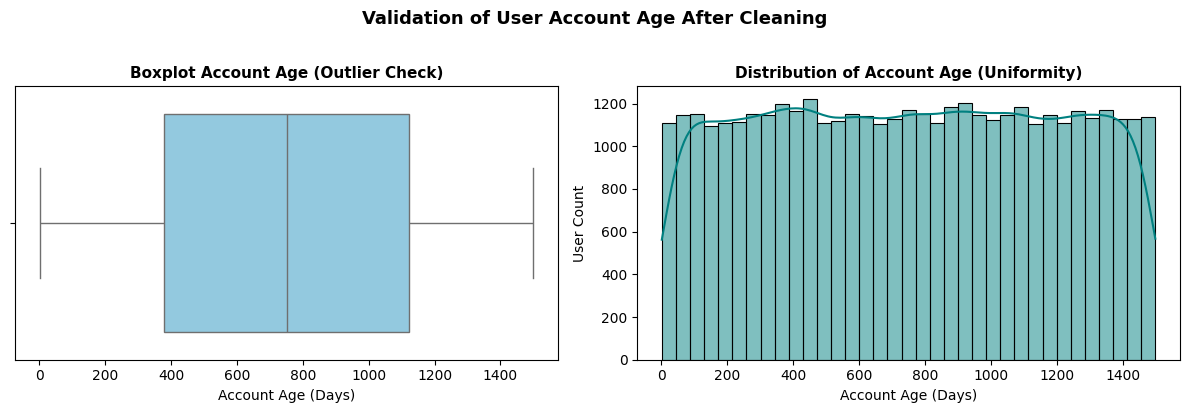

In [589]:
# (3.4.3.1) Validate User Column account_age_days
# Step: Re-check distribution after removing invalid sentinel values
# - Ensures No Outlier values
# - Result is uniformly distributed

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df_users_cleaned["account_age_days"], ax=axes[0], color="skyblue")
axes[0].set_title("Boxplot Account Age (Outlier Check)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Account Age (Days)")

sns.histplot(df_users_cleaned["account_age_days"], ax=axes[1], kde=True, color="teal")
axes[1].set_title("Distribution of Account Age (Uniformity)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Account Age (Days)")
axes[1].set_ylabel("User Count")

plt.suptitle("Validation of User Account Age After Cleaning", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


**3.5 Standardize columns to intended datatypes**

In [576]:
# (3.5.1) Standardize column data types to datetime format
# Step: Convert object/string columns into proper datetime format

df_food_orders_cleaned["order_time"] = pd.to_datetime(
    df_food_orders_cleaned["order_time"],    
    errors="coerce")
df_food_orders_cleaned["driver_arrived_time"] = pd.to_datetime(
    df_food_orders_cleaned["driver_arrived_time"],
    errors="coerce"
)
df_food_orders_cleaned["completed_time"] = pd.to_datetime(
    df_food_orders_cleaned["completed_time"],
    errors="coerce"
)

print(df_food_orders_cleaned["order_time"].dtype)

df_food_orders_cleaned["order_time"].head()

datetime64[ns]


0   2023-12-21 09:43:00
1   2023-12-20 14:01:00
2   2024-02-18 12:56:00
3   2023-12-21 16:12:00
4   2024-02-03 09:13:00
Name: order_time, dtype: datetime64[ns]

In [577]:
# (3.5.2) Feature extraction from order_time
# Step: Extract useful time-based features for analysis
# - Helps understand temporal patterns (year, month, day, day_name)
# - Useful for trend analysis and business reporting

df_food_orders_cleaned["order_year"] = df_food_orders_cleaned["order_time"].dt.year.astype("Int64")
df_food_orders_cleaned["order_month"] = df_food_orders_cleaned["order_time"].dt.month.astype("Int64")
df_food_orders_cleaned["order_day"] = df_food_orders_cleaned["order_time"].dt.day.astype("Int64")
df_food_orders_cleaned["order_day_name"] = df_food_orders_cleaned["order_time"].dt.day_name()

In [578]:
# (3.5.3) Feature extraction from driver_arrived_time
# Step: Extract useful time-based features for analysis
# - Helps understand temporal patterns (year, month, day, day_name)
# - Useful for trend analysis and business reporting

df_food_orders_cleaned["driver_arrived_year"] = df_food_orders_cleaned["driver_arrived_time"].dt.year.astype("Int64")
df_food_orders_cleaned["driver_arrived_month"] = df_food_orders_cleaned["driver_arrived_time"].dt.month.astype("Int64")
df_food_orders_cleaned["driver_arrived_day"] = df_food_orders_cleaned["driver_arrived_time"].dt.day.astype("Int64")
df_food_orders_cleaned["driver_arrived_day_name"] = df_food_orders_cleaned["driver_arrived_time"].dt.day_name()

In [579]:
# (3.5.4) Feature extraction from completed_time
# Step: Extract useful time-based features for analysis
# - Helps understand temporal patterns (year, month, day, day_name)
# - Useful for trend analysis and business reporting

df_food_orders_cleaned["completed_year"] = df_food_orders_cleaned["completed_time"].dt.year.astype("Int64")
df_food_orders_cleaned["completed_month"] = df_food_orders_cleaned["completed_time"].dt.month.astype("Int64")
df_food_orders_cleaned["completed_day"] = df_food_orders_cleaned["completed_time"].dt.day.astype("Int64")
df_food_orders_cleaned["completed_day_name"] = df_food_orders_cleaned["completed_time"].dt.day_name()

In [580]:
df_food_orders_cleaned.dtypes

order_id                           object
merchant_id                        object
user_id                            object
order_status                       object
promo_discount                      int64
cancel_reason                      object
order_time                 datetime64[ns]
driver_arrived_time        datetime64[ns]
completed_time             datetime64[ns]
promo_discount_sentinel              bool
order_year                          Int64
order_month                         Int64
order_day                           Int64
order_day_name                     object
driver_arrived_year                 Int64
driver_arrived_month                Int64
driver_arrived_day                  Int64
driver_arrived_day_name            object
completed_year                      Int64
completed_month                     Int64
completed_day                       Int64
completed_day_name                 object
dtype: object

**3.6 Export The Final Cleaned Results**

In [581]:
# (3.6.1) Export All Results
# Step: Export The Final Clean Results

df_food_orders_cleaned.to_csv("../data/cleaned/grab_food_orders_cleaned.csv", index=False)
df_merchants_cleaned.to_csv("../data/cleaned/grab_merchants_cleaned.csv", index=False)
df_users_cleaned.to_csv("../data/cleaned/users_cleaned.csv", index=False)

## **Section 4. Analytics**

### **4.1 Question 1**

### **4.2 Question 2**

## **Section 5. Conclusion and Recommendation**

**5.1 Conclusion**

**5.2 Recommendation**